In [1]:
# ── Imports ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility ──────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

# ── Load Dataset ─────────────────────────────────────────────────
NUM_WORDS = 10000  # Keep only top 10,000 most frequent words
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print('Training samples :', len(x_train))
print('Test samples     :', len(x_test))
print('Sample review    :', x_train[0][:15], '...')   # Integer indices
print('Label            :', y_train[0], '→', 'Positive' if y_train[0]==1 else 'Negative')
print('Review lengths   : min={}, max={}, mean={:.0f}'.format(
        min(len(r) for r in x_train),
        max(len(r) for r in x_train),
        np.mean([len(r) for r in x_train])))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 122s 7us/step
Training samples : 25000
Test samples     : 25000
Sample review    : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...
Label            : 1 → Positive
Review lengths   : min=11, max=2494, mean=239


In [2]:
dir(imdb)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'get_word_index',
 'load_data']

In [3]:
#PartB - Decoding
# ── Decode a review back to readable English ─────────────────────
word_index = imdb.get_word_index()

# Shift indices by +3 (0=padding, 1=start, 2=unknown, 3=unused)
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'
reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'

def decode_review(encoded_review):
    return ' '.join([reverse_index.get(i, '?') for i in encoded_review])

print('\nDecoded Review 0:')
print(decode_review(x_train[0]))

# ── Label distribution ───────────────────────────────────────────
print('\nClass distribution in training:')
unique, counts = np.unique(y_train, return_counts=True)
print('  Positive:', counts[1], '| Negative:', counts[0])
# → 12500 positive and 12500 negative (perfectly balanced!)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 14s 8us/step

Decoded Review 0:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the wh

In [4]:
#Text Vectorization
# # ── Multi-Hot Encoding Function ──────────────────────────────────
def vectorize_sequences(sequences, dimension=10000):
    """
    Convert a list of integer sequences to a 2D binary matrix.
    Shape: (len(sequences), dimension)
    """
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0   # Set positions of present words to 1
    return results

# Apply vectorization
x_train_vec = vectorize_sequences(x_train, NUM_WORDS)  # Shape: (25000, 10000)
x_test_vec  = vectorize_sequences(x_test,  NUM_WORDS)  # Shape: (25000, 10000)

# Convert labels to float32
y_train = y_train.astype('float32')
y_test  = y_test.astype('float32')

print('x_train_vec shape:', x_train_vec.shape)  # (25000, 10000)
print('x_test_vec  shape:', x_test_vec.shape)   # (25000, 10000)
print('Non-zeros in review 0:', np.sum(x_train_vec[0]), '(unique words present)')


x_train_vec shape: (25000, 10000)
x_test_vec  shape: (25000, 10000)
Non-zeros in review 0: 120.0 (unique words present)


In [5]:
# PartD: train/validation split
# ── Create Validation Set from Training Data ─────────────────────
# Use last 10,000 training samples for validation
VAL_SIZE = 10000

x_val   = x_train_vec[:VAL_SIZE]
x_train_final = x_train_vec[VAL_SIZE:]

y_val   = y_train[:VAL_SIZE]
y_train_final = y_train[VAL_SIZE:]

print('Training samples  :', x_train_final.shape[0])  # 15000
print('Validation samples:', x_val.shape[0])           # 10000
print('Test samples      :', x_test_vec.shape[0])      # 25000


Training samples  : 15000
Validation samples: 10000
Test samples      : 25000


In [6]:
# PartE: Build the neural network model
# ── Model Architecture ───────────────────────────────────────────
def build_model(units=16, dropout_rate=0.5, l2_lambda=0.001, lr=0.001):
    model = keras.Sequential([
        # Layer 1: Dense + ReLU
        layers.Dense(units,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda),
                     input_shape=(NUM_WORDS,),
                     name='hidden_1'),

        # Dropout to prevent overfitting
        layers.Dropout(dropout_rate, name='dropout_1'),

        # Layer 2: Dense + ReLU
        layers.Dense(units,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda),
                     name='hidden_2'),

        layers.Dropout(dropout_rate, name='dropout_2'),

        # Output Layer: 1 neuron + Sigmoid → probability
        layers.Dense(1, activation='sigmoid', name='output')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()


c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# PartF:Train the Model with Early Stopping
# ── Early Stopping Callback ───────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=3,            # Stop if no improvement for 3 epochs
    restore_best_weights=True  # Roll back to best model weights
)

# ── Train ─────────────────────────────────────────────────────────
history = model.fit(
    x_train_final, y_train_final,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining stopped at epoch:', len(history.history['loss']))


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6212 - loss: 0.6906 - val_accuracy: 0.8312 - val_loss: 0.6007
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7585 - loss: 0.5734 - val_accuracy: 0.8677 - val_loss: 0.4824
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8329 - loss: 0.4744 - val_accuracy: 0.8789 - val_loss: 0.4001
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8673 - loss: 0.4073 - val_accuracy: 0.8856 - val_loss: 0.3553
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8964 - loss: 0.3588 - val_accuracy: 0.8883 - val_loss: 0.3351
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9101 - loss: 0.3213 - val_accuracy: 0.8874 - val_loss: 0.3298
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9257 - loss: 0.2931 - val_accuracy: 0.8872 - val_loss: 0.3402
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9334 - loss: 0.2689 - val_accuracy: 0.8861 - v

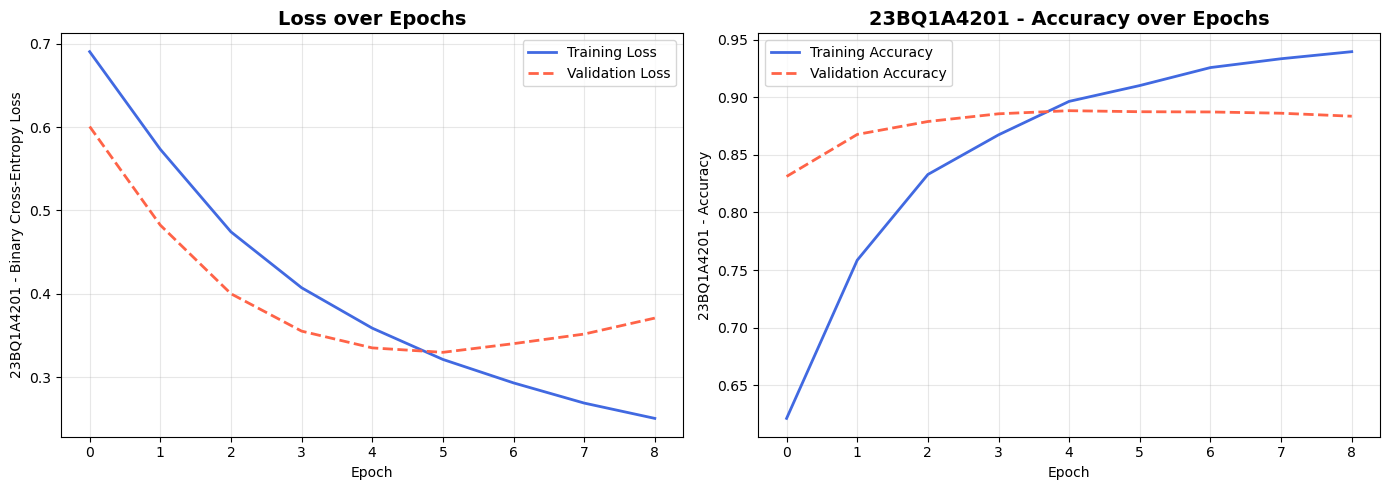

In [10]:
#PartG: plot training graphs
# ── Visualize Training ────────────────────────────────────────────
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'],     label='Training Loss',   color='royalblue', lw=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato',    lw=2, linestyle='--')
    axes[0].set_title('Loss over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('23BQ1A4201 - Binary Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Training Accuracy',   color='royalblue', lw=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato',    lw=2, linestyle='--')
    axes[1].set_title('23BQ1A4201 - Accuracy over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('23BQ1A4201 - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('23BQ1A4201 - exp7_training_curves.png', dpi=150)
    plt.show()

plot_history(history)



Test Loss     : 0.3407
Test Accuracy : 0.8832  (88.32%)
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.88     12500
    Positive       0.89      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



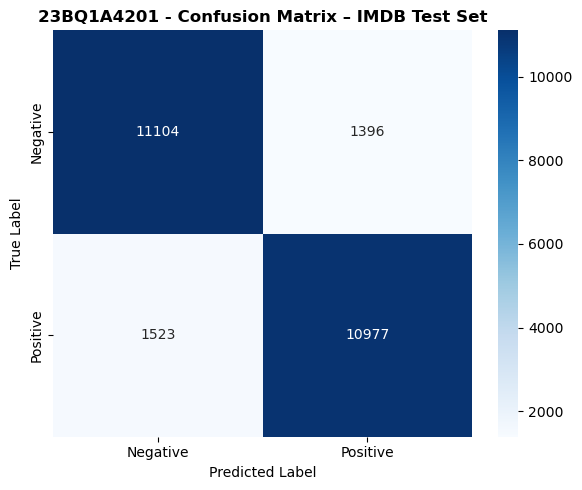

In [11]:
#PartH: Evaluation on test set:
# ── Test Set Evaluation ───────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test_vec, y_test, verbose=0)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

# ── Predictions ───────────────────────────────────────────────────
y_pred_prob = model.predict(x_test_vec)       # Probabilities
y_pred = (y_pred_prob >= 0.5).astype('int32').flatten()  # Convert to 0/1

# ── Classification Report ─────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(y_test.astype(int), y_pred,
                            target_names=['Negative', 'Positive']))

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test.astype(int), y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('23BQ1A4201 - Confusion Matrix – IMDB Test Set', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('23BQ1A4201 - exp7_confusion_matrix.png', dpi=150)
plt.show()


In [12]:
# Part1: Predict on Custom Reveiews
# ── Real-World Sentiment Prediction ──────────────────────────────
def preprocess_custom_review(text, word_index, num_words=10000):
    """Convert a raw string to multi-hot vector for prediction."""
    tokens = text.lower().split()
    seq = [word_index.get(w, 2) + 3 for w in tokens]  # +3 for Keras offset
    seq = [i for i in seq if i < num_words]
    vec = np.zeros((1, num_words))
    vec[0, seq] = 1.0
    return vec

word_index = imdb.get_word_index()

custom_reviews = [
    'This movie was absolutely brilliant. The acting was superb and the story was captivating.',
    'Terrible film. Waste of time. The plot made no sense and the acting was awful.',
    'An average movie. Some good moments but overall pretty mediocre.'
]

print('\n── Custom Review Predictions ──')
for review in custom_reviews:
    vec  = preprocess_custom_review(review, word_index)
    prob = model.predict(vec, verbose=0)[0][0]
    sentiment = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    print(f'Review : {review[:60]}...')
    print(f'Score  : {prob:.4f}  →  {sentiment}')
    print()



── Custom Review Predictions ──
Review : This movie was absolutely brilliant. The acting was superb a...
Score  : 0.5897  →  Positive 😊

Review : Terrible film. Waste of time. The plot made no sense and the...
Score  : 0.1246  →  Negative 😞

Review : An average movie. Some good moments but overall pretty medio...
Score  : 0.5575  →  Positive 😊



In [13]:
#PartJ: Hyperparameter Comparision Experiment
# ── Compare Different Configurations ─────────────────────────────
configs = [
    {'units': 16,  'dropout_rate': 0.5, 'l2_lambda': 0.001, 'lr': 0.001, 'name': 'Baseline'},
    {'units': 32,  'dropout_rate': 0.5, 'l2_lambda': 0.001, 'lr': 0.001, 'name': 'Wider (32 units)'},
    {'units': 16,  'dropout_rate': 0.0, 'l2_lambda': 0.0,   'lr': 0.001, 'name': 'No Regularization'},
    {'units': 64,  'dropout_rate': 0.5, 'l2_lambda': 0.001, 'lr': 0.0001,'name': 'Large + Low LR'},
]

results = []
for cfg in configs:
    m = build_model(cfg['units'], cfg['dropout_rate'], cfg['l2_lambda'], cfg['lr'])
    m.fit(x_train_final, y_train_final, epochs=10, batch_size=512,
          validation_data=(x_val, y_val), verbose=0,
          callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)])
    _, acc = m.evaluate(x_test_vec, y_test, verbose=0)
    results.append({'Config': cfg['name'], 'Test Accuracy': f'{acc*100:.2f}%'})
    print(f"{cfg['name']:30s} → Test Acc: {acc*100:.2f}%")



c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline                       → Test Acc: 88.52%
Wider (32 units)               → Test Acc: 88.46%
No Regularization              → Test Acc: 87.67%
Large + Low LR                 → Test Acc: 86.76%
